Import necessary libraries

In [1]:
import numpy as np
import doppler_dimming_lib as db
import matplotlib.pyplot as plt

/home/herve/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Getting spectrum data from file (precision level 0)...
Done!


Photospheric spectrum is integrated to obtain the coronal brightness. 
Higher wavelenght sampling density leads to more accurate results at the cost of more computation time.
There are three spectrum available:

- set_spectrum_level(0): Thekaekara spectum (default), faster but less accurate
- set_spectrum_level(1): Thuillier spectum 
- set_spectrum_level(2): MODTRAN synthetic spectum, slower but accurate

Getting spectrum data from file (precision level 2)...
Done!
Getting spectrum data from file (precision level 1)...
Done!
Getting spectrum data from file (precision level 0)...
Done!


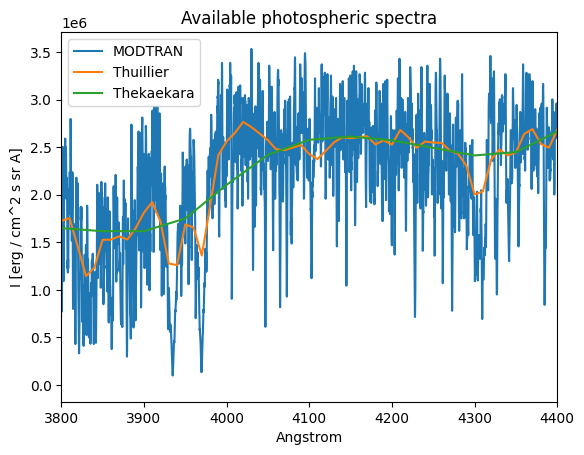

In [2]:
db.set_spectrum_level(0)

fig, ax = plt.subplots()
for i, label in enumerate(["MODTRAN", "Thuillier", "Thekaekara"]):
    wls, Is = db.get_spectrum_from_txt(2 - i)
    ax.plot(wls * 1.0e8, Is, label=label)

ax.set_xlim(3800, 4400)
ax.set_title("Available photospheric spectra")
ax.set_xlabel("Angstrom")
ax.set_ylabel("I [erg / cm^2 s sr A]")
ax.legend()

# free memory
wls = None
Is = None

The core function of the library is integrals.integrated_I_s(), providing the K-corona emission in [erg cm-2 A-1 s-1 sr-1] ( $I_s^{\lambda}({\rho})$ , Eq 1 from Reginald & Davila, 2000) for a given wavelenght and heliocentric distance.

If the provided electron density is a function, the LOS integral is performed in the range x=(-inf, inf). 

In [3]:
rho = 3.0  # heliocentric distance, Rsun
T_e = 1.0e6  # temperature, K
wind_speed = 0  # wind speed, km/s
_lambda = 4700  # wavelenght, angstrom
N_e_function = (
    db.utils.N_e_analytical
)  # function used to obtain the electron density from the heliocentric distance, in particles/cm^3. N_e_analytical is an analytical form, but other forms can be used as long as they have the signature float: N_e(float: x) -> float
component = 3  # polarized component to obtain. 0 is radial, 1 is tangent, 2 is pb, 3 is the sum of radial+tangent

I_s_lambda = db.integrated_I_s(
    rho=rho,
    _lambda=_lambda,
    T_e=T_e,
    wind_speed=wind_speed,
    component=component,
    N_e_function=N_e_function,
    verbose=True,
)

print(f"\n{I_s_lambda = } [erg cm-2 A-1 s-1 sr-1]")


Calculating I_s_lambda...
_lambda = 4700 Angstrom
rho = 3.0 R_sun
T_e = 1000000.0 K
wind_speed = 0 Km/s

I_s_lambda = 0.015929744052281154 [erg cm-2 A-1 s-1 sr-1]


The integral can be performed for each wavelenght in a selected range, providing the K-corona spectrum.

Getting spectrum data from file (precision level 1)...
Done!


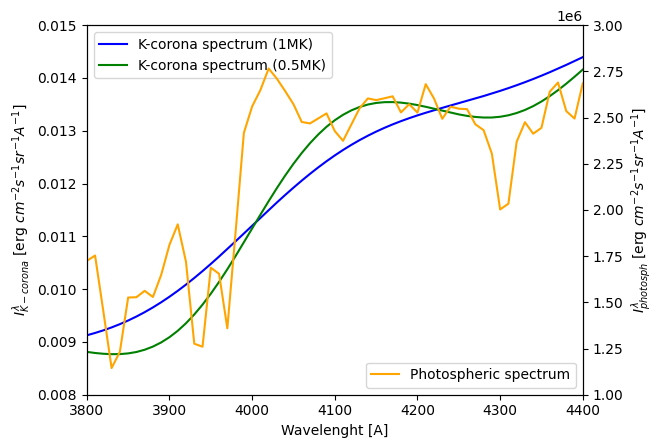

In [4]:
wls, Is = db.get_spectrum_from_txt(1)
wls = wls * 1.0e8  # convert from cm to angstrom

Is = Is[(wls > 3000) & (wls < 5000)]
wls = wls[(wls > 3000) & (wls < 5000)]

I_s_lambdas_2M = np.zeros_like(wls)
I_s_lambdas_05M = np.zeros_like(wls)
for i, wl in enumerate(wls):
    I_s_lambdas_2M[i] = db.integrated_I_s(
        rho=rho,
        _lambda=wl,
        T_e=2.0e6,
        wind_speed=wind_speed,
        component=3,
        verbose=False,
    )
    I_s_lambdas_05M[i] = db.integrated_I_s(
        rho=rho,
        _lambda=wl,
        T_e=0.5e6,
        wind_speed=wind_speed,
        component=3,
        verbose=False,
    )

fig, ax = plt.subplots()
ax.set_xlim(3800, 4400)
ax.set_ylim(0.008, 0.015)
ax1 = ax.twinx()
ax1.set_ylim(1.0e6, 3.0e6)
ax.plot(wls, I_s_lambdas_2M, label="K-corona spectrum (1MK)", color="blue")
ax.plot(wls, I_s_lambdas_05M, label="K-corona spectrum (0.5MK)", color="green")
ax1.plot(wls, Is, label="Photospheric spectrum", color="orange")

ax.set_xlabel("Wavelenght [A]")
ax.set_ylabel(r"$I^\lambda_{K-corona}$ [erg $cm^{-2} s^{-1} sr^{-1} A^{-1}$]")
ax1.set_ylabel(r"$I^\lambda_{photosph}$ [erg $cm^{-2} s^{-1} sr^{-1} A^{-1}$]")

ax1.legend(loc="lower right")
ax.legend(loc="upper left")

If CODEX images are not available, CODEX data can be simulated based on the convolution between the expected signal and the filter transmissivities measured in lab.

Functions such as codex.simulate_codex_images() can be used to simulate 2d arrays of pixels faster by distributing the computation across processors, reducing the wall time.

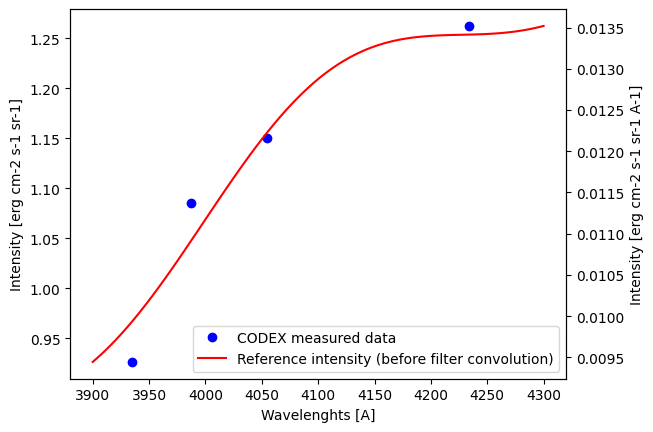

In [32]:
# Simulate codex measure by integrating the emission and convolving each filter response
codex_measures = t1, s1, t2, s2 = db.simulate_codex_measure(
    rho=rho,
    T_e=T_e,
    wind_speed=wind_speed,
    N_e_function=N_e_function,
    verbose=False,
)


dense_wls = np.linspace(3900, 4300, 100)
reference_brightness = [
    db.integrated_I_s(rho, _lambda, T_e, wind_speed, 3, verbose=False)
    for _lambda in dense_wls
]

wls = [val for val in db.FILTER_CENTERS.values()]


fig, ax = plt.subplots()
ax2 = ax.twinx()
lns1 = ax.plot(wls, codex_measures, "bo", label="CODEX measured data")
ax.set_xlabel("Wavelenghts [A]")
ax.set_ylabel("Intensity [erg cm-2 s-1 sr-1]")

lns2 = ax2.plot(
    dense_wls,
    reference_brightness,
    color="red",
    label="Reference intensity (before filter convolution)",
)
ax2.set_ylabel("Intensity [erg cm-2 s-1 sr-1 A-1]")

lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc="lower right")

Electron temperature is obtained with the following steps:

- Calculate the expected K-corona intensity $I_{i}(T_{1-5})$ at 5 different temperatures T (from 0.5MK to 3MK) for a filter $i$ among T1, S1, T2, S2
- Repeat for another filter j and obtain the 5 ratios $R_{i/j}^{I}(T_{1-5}) = I_{i}(T_{1-5}) / I_{j}(T_{1-5})$
- Obtain the cubic spline interpolator of $R^I_{i/j}(T_{1-5})$ and invert it to obtain $T(R_{i/j}^{I})$
- Obtain the estimated temperature $T_e$ at the measured ratio $T_e = T(R^J_{i/j})$

Note: $J_{i}(T_{1-5}) = \int I_{i}(T_{1-5}) t(\lambda) d\lambda$ , , where $t(\lambda)$ is the filter transmissivity  
Therefore $R^J_{i/j} = \int I_{i}(T_{1-5}) t(\lambda)d\lambda / \int I_{j}(T_{1-5}) t(\lambda)d\lambda$ 

The measured ratio $R^J$ is different from the estimated ratio $R^I$, since the latter does not account for the filter response convolution. The estimated temperature obtained with this approximation is typically different than the true temperature (<15\%), but its computation is significally faster. 

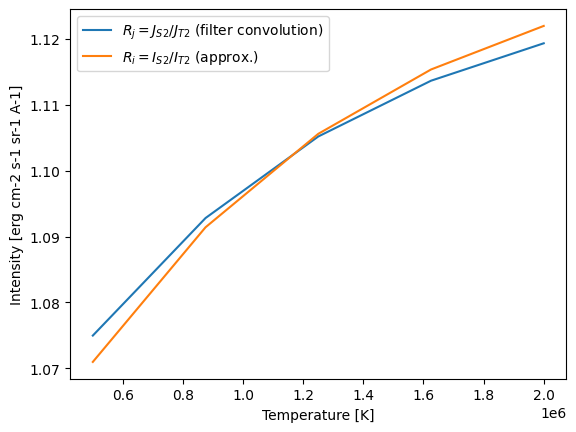

In [31]:
five_Ts = np.linspace(5.0e5, 2.0e6, 5)

first_filter_name = "S2"
second_filter_name = "T2"

R_is = np.zeros_like(five_Ts)
R_js = np.zeros_like(five_Ts)


for i, T in enumerate(five_Ts):
    I1, I2 = [
        db.integrated_I_s(
            rho=rho,
            _lambda=db.FILTER_CENTERS[filter_name],
            T_e=T,
            wind_speed=wind_speed,
            component=3,
            verbose=False,
        )
        for filter_name in [first_filter_name, second_filter_name]
    ]
    R_is[i] = I1 / I2

    J1, J2 = [
        db.simulate_codex_filter(
            filter_name, rho=rho, T_e=T, wind_speed=wind_speed, verbose=False
        )
        for filter_name in [first_filter_name, second_filter_name]
    ]
    R_js[i] = J1 / J2


fig, ax = plt.subplots()
ax.plot(
    five_Ts,
    R_js,
    label=rf"$R_{{j}} = J_{{{first_filter_name}}} / J_{{{second_filter_name}}}$ (filter convolution)",
)
ax.plot(
    five_Ts,
    R_is,
    label=rf"$R_{{i}} = I_{{{first_filter_name}}} / I_{{{second_filter_name}}}$ (approx.)",
)


ax.set_xlabel("Temperature [K]")
ax.set_ylabel(r"Intensity [erg cm-2 s-1 sr-1 A-1]")

ax.legend()

In [ ]:
# obtain spline interpolator, that is T(R^i)
spline_T_from_R = db.get_R_as_spline(
    integral_function=db.I_s_lambda,  # function to use
    lambda1=db.FILTER_CENTERS["S2"],  # numerator filter wavelenght
    lambda2=db.FILTER_CENTERS["T2"],  # denominator filter wavelenght
    rho=rho,  # parameters passed to the function
    wind_speed=wind_speed,
)

# Estimate T from ratio of the above cell
T_estimated = spline_T_from_R(s2 / t2)

print(f"Estimated temperature: {T_estimated}")
print(f"Real temperature: {T_e}")

Estimated temperature: 1018242.5928526497
Real temperature: 1000000.0


The above code works for any couple of filters. The specific ratio between S2 and T2, that is $R_{S2/T2}$, is implemented in a standalone function codex.get_T_from_R()

In [7]:
# get_T_from_R() only works with the specific ratio S2/T2 !!!
ratio = s2 / t2
temperature = db.get_T_from_R(ratio, rho=rho)

print("Estimated temperature R_{S2/T2}" + f": {temperature}")

Estimated temperature R_{S2/T2}: 1018242.5928526497


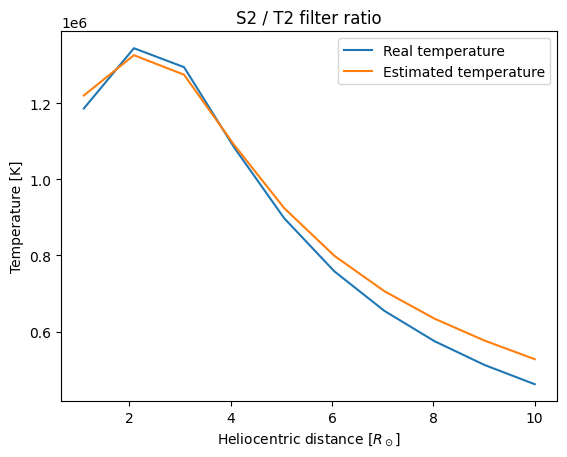

In [8]:
# obtain a sequence of temperatures (hydrostatic corona)
rhos = np.linspace(1.1, 10, 10)
Ts = np.array([db.T_e_analytical(rho) for rho in rhos])

ratios = np.array(
    [
        db.simulate_codex_filter("S2", rho, T_e, wind_speed=0, verbose=False)
        / db.simulate_codex_filter("T2", rho, T_e, wind_speed=0, verbose=False)
        for rho, T_e in zip(rhos, Ts)
    ]
)
estimated_Ts = np.array(
    [db.get_T_from_R(ratio, rho) for ratio, rho in zip(ratios, rhos)]
)

fig, ax = plt.subplots()
ax.plot(rhos, Ts, label="Real temperature")
ax.plot(rhos, estimated_Ts, label="Estimated temperature")
ax.set_xlabel(r"Heliocentric distance [$R_\odot$]")
ax.set_ylabel("Temperature [K]")
ax.set_title("S2 / T2 filter ratio")
ax.legend()